In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch 

#add ../ to the path
import sys
sys.path.insert(0, '../')

import evaluate_utils.eval_utils
import viz_utils.viz
import data_utils.pv_utils
import importlib
importlib.reload(evaluate_utils.eval_utils)
importlib.reload(viz_utils.viz)
importlib.reload(data_utils.pv_utils)
from evaluate_utils.eval_utils import *
from viz_utils.viz import * 
from data_utils.pv_utils import * 

In [5]:
RRUFF_non_aug_model = result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf/RRUFF_data_test_only_using_amcsd', num_evals = 64)
RRUFF_aug_model = result_data('/home/gridsan/tmackey/hydra/singlerun/2024-01-29/augmented_vae_nopf/RRUFF_data_test_only_using_amcsd', num_evals = 64)    

100%|██████████| 64/64 [00:04<00:00, 15.20it/s]


In [6]:
import torch
import pandas as pd

snapped_crystal_list = torch.load("/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/RRUFF/data/snapped_crystal_list.pt")
gt_crystal_list = torch.load("/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/RRUFF/data/gt_crystal_list.pt")
pre_snap_crystal_list = torch.load("/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/RRUFF/data/pre_snap_crystal_list.pt")

snapped_cosine_sim = get_cosine_similarities_from_crystal_lists(snapped_crystal_list[0], gt_crystal_list[0])
pre_snapped_cosine_sim = get_cosine_similarities_from_crystal_lists(pre_snap_crystal_list[0], gt_crystal_list[0])


100%|██████████| 68/68 [00:14<00:00,  4.69it/s]


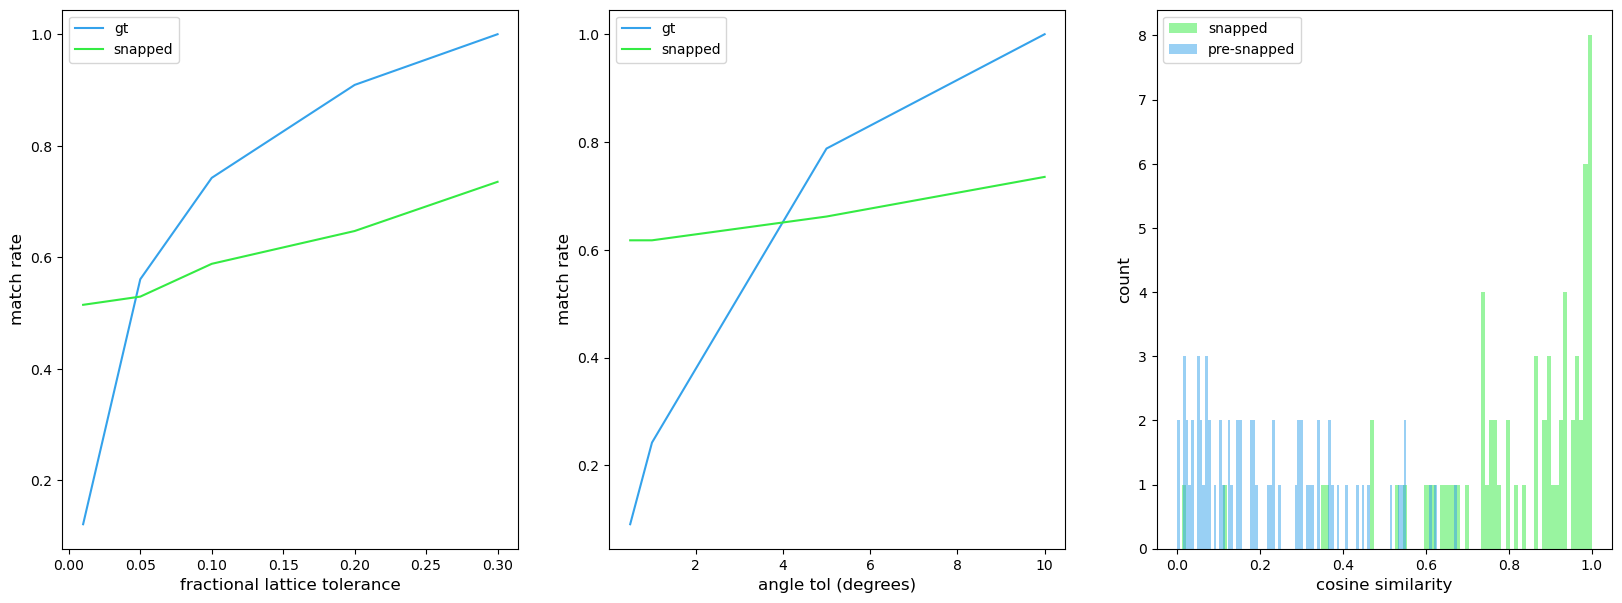

In [7]:
fig, axs = plt.subplots(1, 3, figsize = (20, 7))
ltol_values = [0.01, 0.05, 0.1, 0.2, 0.3]
angle_tol_values = [0.5, 1.0, 5.0, 10.0]

snapped_color = "#34eb43"
gt_color = "#34a2eb"
fontsize = 12

axs[0].plot(ltol_values, RRUFF_aug_model.ltols_per_tol[:, 63] * 1 / (np.max(RRUFF_aug_model.ltols_per_tol[:, 63])) , label = 'gt', color = gt_color)
axs[0].plot(ltol_values, RRUFF_aug_model.snapped_ltols_per_tol[:, 0], label = 'snapped', color = snapped_color)
axs[0].legend()
axs[0].set_xlabel('fractional lattice tolerance', fontsize = fontsize)  # X-axis label for the first plot
axs[0].set_ylabel('match rate', fontsize = fontsize)  # Y-axis label for the first plot'

axs[1].plot(angle_tol_values, RRUFF_aug_model.atols_per_tol[:, 63] * 1 / (np.max(RRUFF_aug_model.atols_per_tol[:, 63])), label = 'gt', color = gt_color)
axs[1].plot(angle_tol_values, RRUFF_aug_model.snapped_atols_per_tol[:, 0], label = 'snapped', color = snapped_color)
axs[1].set_xlabel('angle tol (degrees)', fontsize = fontsize)  # X-axis label for the second plot
axs[1].set_ylabel('match rate', fontsize = fontsize)  # Y-axis label for the second plot")
axs[1].legend()

axs[2].hist(snapped_cosine_sim, bins = 100, color = snapped_color, alpha = 0.5)
axs[2].hist(pre_snapped_cosine_sim , bins = 100, color = gt_color, alpha = 0.5)
axs[2].set_xlabel('cosine similarity', fontsize = fontsize)  # X-axis label for the second plot
axs[2].set_ylabel('count', fontsize = fontsize)  # Y-axis label for the second plot")
axs[2].legend(['snapped', 'pre-snapped'])

In [8]:
#make a dataframe with all of the data in it 
gt_match_rate_vs_frac_tol = RRUFF_aug_model.ltols_per_tol[:, 63] * 1 / (np.max(RRUFF_aug_model.ltols_per_tol[:, 63]))
frac_tols, snapped_match_rate_vs_frac_tol = ltol_values, RRUFF_aug_model.snapped_ltols_per_tol[:, 0]

frac_tol_df = pd.DataFrame({'frac_tols': frac_tols, 'snapped': snapped_match_rate_vs_frac_tol, 'pre_snapped': gt_match_rate_vs_frac_tol})

gt_match_rate_vs_angle_tol = RRUFF_aug_model.atols_per_tol[:, 63] * 1 / (np.max(RRUFF_aug_model.atols_per_tol[:, 63]))
angle_tols, snapped_match_rate_vs_angle_tol = angle_tol_values, RRUFF_aug_model.snapped_atols_per_tol[:, 0]

angle_tol_df = pd.DataFrame({'angle_tols': angle_tols, 'snapped': snapped_match_rate_vs_angle_tol, 'pre_snapped': gt_match_rate_vs_angle_tol})

cosine_sim_df = pd.DataFrame({'snapped': snapped_cosine_sim, 'pre_snapped': pre_snapped_cosine_sim})

In [9]:
results_dir = "/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/RRUFF/data/results_data"

frac_tol_df.to_csv(results_dir + "/frac_tol_df.csv")
angle_tol_df.to_csv(results_dir + "/angle_tol_df.csv")
cosine_sim_df.to_csv(results_dir + "/cosine_sim_df.csv")
